<h1>Table of Contents<span class="tocSkip"></span></h1>  

<div class="toc"><ul class="toc-item">
<li><span><a href="#安装依赖包" data-toc-modified-id="安装依赖包-1">安装依赖包</a></span></li>
<li><span><a href="#数据清洗" data-toc-modified-id="数据清洗-2">数据清洗</a></span></li>
<li><span><a href="#数据可视化" data-toc-modified-id="数据可视化-3">数据可视化</a></span></li>
<li><span><a href="#构建猪肉价格预测模型" data-toc-modified-id="构建猪肉价格预测模型-4">构建猪肉价格预测模型</a></span>
    <ul class="toc-item">
    <li><span><a href="#多特征模型训练（多元线性回归）" data-toc-modified-id="多特征模型训练（多元线性回归）-4.1">多特征模型训练（多元线性回归）</a></span></li>
    <li><span><a href="#假设验证法选出最佳特征组合" data-toc-modified-id="假设验证法选出最佳特征组合-4.2">假设验证法选出最佳特征组合</a></span></li>
    </ul>
</li>
<li><span><a href="#猪肉价格的预测" data-toc-modified-id="猪肉价格的预测-5">猪肉价格的预测</a></span></li>
</ul></div>

# 安装依赖包

In [144]:
!pip install pandas -i https://pypi.tuna.tsinghua.edu.cn/simple/

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple/

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


# 数据清洗

In [142]:
import numpy as np
import pandas as pd

In [109]:
data = pd.read_csv('/Users/xiaozi/Desktop/猪肉数据.csv') 
data.head()

,年份,pork_price（白条猪批发均价，元 / 公斤）,sow_stock（能繁母猪存栏，万头）,corn_price（玉米批发均价，元 / 吨）,bean_meal_price（豆粕批发均价，元 / 吨）,hog_out_price（生猪出场价，元 / 公斤）,pork_import（猪肉进口量，万吨 / 年）
0,2006,12.4,4850,1380,2250,9.7,26.4
1,2007,18.6,4320,1520,2580,14.8,30.0
2,2008,22.8,4760,1680,3200,17.9,37.2
3,2009,17.2,4980,1540,2850,13.5,45.6
4,2010,19.5,4640,1890,3420,15.2,50.4


In [110]:
#列名只保留英文
data.columns = [
    'year',
    'pork_price',
    'sow_stock',
    'corn_price',
    'bean_meal_price',
    'hog_out_price',
    'pork_import'
]

print(data.columns)
print(data.head())

Index(['year', 'pork_price', 'sow_stock', 'corn_price', 'bean_meal_price',
       'hog_out_price', 'pork_import'],
      dtype='object')
   year  pork_price  sow_stock  corn_price  bean_meal_price  hog_out_price  \
0  2006        12.4       4850        1380             2250            9.7   
1  2007        18.6       4320        1520             2580           14.8   
2  2008        22.8       4760        1680             3200           17.9   
3  2009        17.2       4980        1540             2850           13.5   
4  2010        19.5       4640        1890             3420           15.2   

   pork_import  
0         26.4  
1         30.0  
2         37.2  
3         45.6  
4         50.4  


In [111]:
# 删除index列（用del更方便）
data.drop('year',axis=1,inplace=True) 
data.head()

,pork_price,sow_stock,corn_price,bean_meal_price,hog_out_price,pork_import
0,12.4,4850,1380,2250,9.7,26.4
1,18.6,4320,1520,2580,14.8,30.0
2,22.8,4760,1680,3200,17.9,37.2
3,17.2,4980,1540,2850,13.5,45.6
4,19.5,4640,1890,3420,15.2,50.4


In [112]:
#过滤异常值（非洲猪瘟 outliers）
df = data[data['sow_stock'] >= 4000] 

# 数据可视化

In [113]:
data['sow_stock']

0     4850
1     4320
2     4760
3     4980
4     4640
5     4280
6     4570
7     4890
8     4350
9     4020
10    4290
11    4560
12    4210
13    2050
14    2780
15    4330
16    4490
17    4120
18    3960
19    3920
Name: sow_stock, dtype: int64

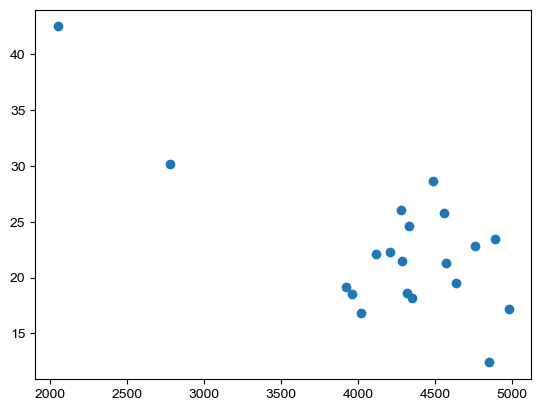

In [114]:
import matplotlib.pyplot as plt
sow = data['sow_stock']
price = data['pork_price']
plt.scatter(sow,price)
plt.show() # 有离群点数据，对线性分析不利，需要过滤

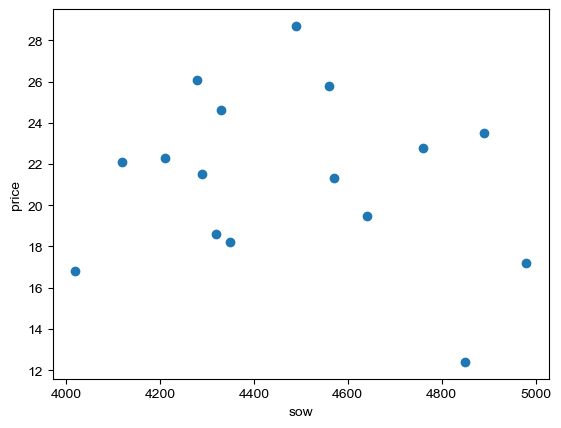

In [115]:
df = data[data['sow_stock'] >=4000] # 正常住宅面积小于等于300平米
sow = df['sow_stock']
price = df['pork_price']
#print(sow.count()) #过滤后的数据量
plt.scatter(sow,price)
plt.xlabel("sow")
plt.ylabel("price")
plt.show()

# 构建猪肉价格预测模型

In [116]:
# 先根据可育母猪存栏和平均单价训练模型（一元线性回归）
from sklearn.linear_model import LinearRegression
linear = LinearRegression()
sow = np.array(sow).reshape(-1,1) 
price = np.array(price).reshape(-1,1)
# 训练模型
model = linear.fit(sow,price)
# 打印截距和回归系数
print(model.intercept_, model.coef_)

[32.34597974] [[-0.00245794]]


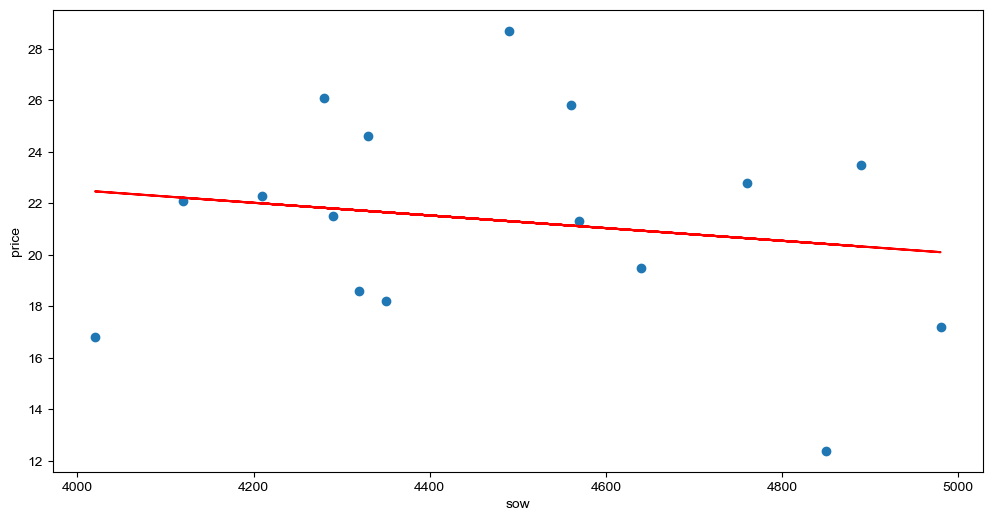

In [117]:
# 线性回归可视化(数据拟合)
linear_p = model.predict(sow)
plt.figure(figsize=(12,6))
plt.scatter(sow,price)
plt.plot(sow,linear_p,'red')
plt.xlabel("sow")
plt.ylabel("price")
plt.show()

## 多特征模型训练（多元线性回归）

In [118]:
X = df[['sow_stock', 
        'corn_price', 
        'bean_meal_price', 
        'hog_out_price', 
        'pork_import']]

In [119]:
y = df['pork_price']

In [121]:
print(type(X))
print(type(y))
# 使用train_test_split进行交叉验证
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=12)
print(x_train.shape,y_train.shape)
print(x_test.shape,y_test.shape)

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>
(12, 5) (12,)
(4, 5) (4,)


In [122]:
# 模型训练
linear = LinearRegression()
model = linear.fit(x_train,y_train)
print(model.intercept_, model.coef_)

-3.7271100077635175 [ 5.84114606e-04  8.75401770e-04 -1.45703124e-04  1.26996665e+00
  1.71898298e-03]


In [123]:
# 模型性能评分
price_end = model.predict(x_test)
score = model.score(x_test,y_test) 
print("模型得分：",score)# 一般模型在0.6以上就表现的不错

模型得分： 0.9974281918585984


## 假设验证法选出最佳特征组合

In [124]:
# 使用假设验证法，选出最佳特征组合
cols = ['sow_stock', 
        'corn_price', 
        'bean_meal_price', 
        'hog_out_price', 
        'pork_import']
import statsmodels.api as sm
Y = df['pork_price']
X = df[cols]
X_ = sm.add_constant(X) #增加一列值为1的const列，保证偏置项的正常
#print(X_)
# 使用最小平方法
result = sm.OLS(Y,X_)
# 使用fit方法进行计算
summary = result.fit()
# 调用summary2方法打印出假设验证信息（性能指标）
summary.summary2() # R-squared:模型评分 AIC：组合完越小越好

/Users/xiaozi/anaconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=16
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


<class 'statsmodels.iolib.summary2.Summary'>
"""
                 Results: Ordinary least squares
=================================================================
Model:              OLS              Adj. R-squared:     0.997   
Dependent Variable: pork_price       AIC:                0.8217  
Date:               2026-05-22 17:31 BIC:                5.4572  
No. Observations:   16               Log-Likelihood:     5.5891  
Df Model:           5                F-statistic:        1089.   
Df Residuals:       10               Prob (F-statistic): 2.42e-13
R-squared:          0.998            Scale:              0.046583
-----------------------------------------------------------------
                   Coef.  Std.Err.    t    P>|t|   [0.025  0.975]
-----------------------------------------------------------------
const             -4.5610   1.3723 -3.3236 0.0077 -7.6186 -1.5033
sow_stock          0.0007   0.0003  2.7396 0.0208  0.0001  0.0014
corn_price         0.0009   0.0004  2.3331 0.0418  0.0000  0.0017
bean_meal_price   -0.0003   0.0004 -0.6144 0.5527 -0.0012  0.0007
hog_out_price      1.2915   0.0479 26.9770 0.0000  1.1848  1.3981
pork_import        0.0027   0.0014  1.9813 0.0757 -0.0003  0.0058
-----------------------------------------------------------------
Omnibus:               1.426       Durbin-Watson:          2.081 
Prob(Omnibus):         0.490       Jarque-Bera (JB):       0.484 
Skew:                  0.420       Prob(JB):               0.785 
Kurtosis:              3.143       Condition No.:          153411
=================================================================
Notes:
[1] Standard Errors assume that the covariance matrix of the
errors is correctly specified.
[2] The condition number is large, 1.53e+05. This might indicate
that there are strong multicollinearity or other numerical
problems.
"""

#### 名词解释
- coef 回归系数
- Std.Err 标准差
- t 虚无假设成立时的t值
- P>|t| 虚无假设成立时的概率值
- [0.025,0.975] 97.5%置信估计区间
- 要做假设性验证，首先要设置显著性标准。
- a. 假设显著性标准是0.01
- b. 推翻虚无假设的标准是p<0.01
- c. 上面的SqFt的t=9.2416，P(>5) = 0.0000 < 0.01,因此虚无假设被推翻（这里的虚无假设是SqFt对price的回归系数为0，即SqFt与price不相关）

---

#### F统计
- 回归平方和 Regression Square Sum[RSS]: 依变量的变化归咎于回归模型 A=sum((y-y_)^2)
- 误差平方和 Error Square Sum[ESS]: 依变量的变化归咎于线性模型 B=sum((y-y_)^2)
- 总的平方和 Total Square Sum[TSS]: 依变量整体变化 C=A+B
- 回归平方平均 Model Mean Square:=RSS/Regression d.f(k) k=自变量的数量
- 误差平方平均 Error Mean square:=ESS/Error d.f(n-k-1) n=观测值得数量
- F统计 F=Model Mean Square /Error Mean Square
- F值越大越好，Prob(F-statistic)越小越好

---

#### R Square
- 回归可以解释变量比例，可以作为自变量预测因变量准确度的指标
- SSE(残差平方和) = sum((y-y_)^2)
- SST(整体平方和) = sum((yi-yavg)^2)
- R^2 = 1-SEE/SST 一般要大于0.6,0.7才算好

---

#### Adjust R Square
- R^2 = 1-SSE/SST SSE最小，推导出R^2不会递减
- yi = b1x1 + b2x2 +...+bkxk+...增加任何一个变量都会增加R^2
- Adj R^2 = 1-(1-R^2) * ((n-1)/(n-p-1))
- n为总体大小，p为回归因子个数

---

#### AIC/BIC
- AIC(The Akaike Information Criterion)= 2K + nln(SSE/n) K是参数数量，n是观察数，SSE是残差平方和。
- AIC鼓励数据拟合的优良性，但是应该尽量避免过拟合，所以优先考虑的模型应该是AIC最小的那一个。
- 赤池信息量的准则是寻找可以最好的解释数据但是包含最少自由参数的模型。

In [68]:
import itertools

list1 = [1, 2,3, 4, 5,6,7,8,9,10,11,12,13,14,15,16] #特征超过16个将发生异常
list2 = []
for i in range(1, len(list1)+1):
    iter1 = itertools.combinations(list1, i)
    list2.append(list(iter1))
#print(list2)

In [125]:
import itertools
# 使用itertools，找出AIC最小值的特征组合作为模型训练的特征
# 寻找最小AIC值的特征组合
fileds = ['sow_stock', 
        'corn_price', 
        'bean_meal_price', 
        'hog_out_price', 
        'pork_import']
acis = {}
for i in range(1,len(fileds)+1):
    for virables in itertools.combinations(fileds,i): #从fileds中随机选择i个特征机型组合，返回的virables为元组类型
        x1 = sm.add_constant(df[list(virables)])
        x2 = sm.OLS(Y,x1)
        res = x2.fit()
        acis[virables] = res.aic # AIC评分越小越好

In [126]:
from collections import Counter
# 对字典进行统计
counter = Counter(acis)
# 降序选出AIC最小的5个数，也就是最佳特征组合
counter.most_common()[-5:] 

[(('sow_stock', 'bean_meal_price', 'hog_out_price', 'pork_import'),
  5.774960642020254),
 (('sow_stock', 'corn_price', 'bean_meal_price', 'hog_out_price'),
  4.119767285768297),
 (('sow_stock', 'corn_price', 'hog_out_price'), 3.7022443664128915),
 (('sow_stock',
   'corn_price',
   'bean_meal_price',
   'hog_out_price',
   'pork_import'),
  0.8217007678713486),
 (('sow_stock', 'corn_price', 'hog_out_price', 'pork_import'),
  -0.5854178162816552)]

In [128]:
# 接下来使用AIC值最小的特征组合进行预测
col2 = ['sow_stock','corn_price', 'hog_out_price', 'pork_import']
X = df[col2]
y = df['pork_price']

x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=13)
linear = LinearRegression()
model = linear.fit(x_train,y_train)
model.score(x_test,y_test) 

0.9918007241208991

# 猪肉价格的预测

#### 现在我们可以根据给定的最佳特征组合进行预测猪肉

In [141]:
# 输入4个特征预测
p_price = [3950, 2550, 16, 78]
predict_data = np.array(p_price).reshape(1, -1)
pred = model.predict(predict_data)
# 输出结果
print("预测猪肉价格 =", pred[0])

预测猪肉价格 = 20.762211968679782


/Users/xiaozi/anaconda3/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
